# 1. Introduction

`03_eir-transformer.ipynb` trains a GPT style transformer on simulated EHR trajectories by writing a few YAML files and calling `eirtrain` on them. Here we go through those files, and the two commands, on their own first.

- **Sections 2-3**: read configs that are already in the repository
- **Sections 4-6**: simulate a small dataset, train a real (if tiny) model on it, and predict with it - about a minute on a laptop CPU

> **Note**: This notebook stands on its own, and only writes to `reference_data/eir-intro-demo/` and `runs/eir-intro-demo/`.

## 1.1 From EIR-auto-GP to EIR

```
   EIR-auto-GP     "here is genotype data, give me predictions"   <- previous notebook
        |
        v
       EIR         "here are my inputs, my target, my model size" <- this course, from now on
        |
        v
     PyTorch       "here are the exact tensors and layers"        <- not in this course
```

- In the GRS notebook we handed `EIR-auto-GP` genotype data and got predictions back, without ever describing a model
- Under the hood it calls `EIR`, and going one layer down means we pick the inputs, the target and the model size ourselves
- We do that in YAML rather than in Python

## 1.2 Why YAML rather than Python

Setting up a DL model is mostly *description* (which file, how many epochs, how wide, where to save) and relatively little logic. Taking that description out of the code is convenient for a few reasons:

- We can `diff` two models, e.g. the GRS model here differs from the baseline by a single extra file
- EIR copies the resolved configs into the run folder, so later on we can go back and see exactly what produced a given checkpoint
- Anything not in the YAML is at its default, and the defaults are documented in the [EIR docs](https://eir.readthedocs.io/en/stable/)

The cost is that we need to know which file a given setting belongs in, which is what section 2 is about.

# 2. The four kinds of config

```
   input 1  ──┐
   input 2  ──┼──►  fusion  ──►  output
   input 3  ──┘
```

One config type per box, plus the global config for everything else:

| config | one file per | answers |
|---|---|---|
| **global** | run (exactly one) | how long to train, where to save, learning rate |
| **input** | input (zero or more) | which file, which columns, how to encode them |
| **fusion** | run (zero or one) | how to combine multiple inputs |
| **output** | output (one or more) | what to predict, and how big the output head is |

- Two of them can be left out, and it is perhaps not obvious which two
- A sequence generation model needs **no input config** (section 2.3)
- But it **does need a fusion config**, even with nothing to fuse (section 2.4)

In [1]:
!ls -1 ../configs/eir-transformer/ ../configs/eir-transformer-with-grs/

../configs/eir-transformer-with-grs/:
fusion.yaml
globals.yaml
input_tabular.yaml
input_tabular_test.yaml
output_sequence.yaml
output_sequence_test.yaml

../configs/eir-transformer/:
fusion.yaml
globals.yaml
output_sequence.yaml
output_sequence_test.yaml


- `eir-transformer` - the baseline model, without GRS. Note there is no `input_*.yaml` at all (section 2.3)
- `eir-transformer-with-grs` - the same model, with GRS values as an extra input
- `*_test.yaml` - the same configs pointed at the test data, used at prediction time

## 2.1 The global config

The "everything else" file: settings for the run as a whole, rather than for a single input or output.

In [2]:
!cat ../configs/eir-transformer/globals.yaml

basic_experiment:
  memory_dataset: true
  n_epochs: 20
  output_folder: ../runs/ehr_transformer
  manual_valid_ids_file: ../reference_data/eir-transformer/validation_ids.txt
evaluation_checkpoint:
  checkpoint_interval: 500
  n_saved_models: 1
  sample_interval: 500
optimization:
  lr: 0.0006
latent_sampling:
  layers_to_sample:
  - output_modules.ehr.final_norm

| key | meaning |
|---|---|
| `memory_dataset: true` | load the whole dataset into RAM, fine here as the data is small |
| `n_epochs: 20` | 20 passes over the training data |
| `output_folder` | **everything** the run produces lands here |
| `manual_valid_ids_file` | IDs held out for validation. Fixed by hand so the baseline and GRS models are validated on *the same* individuals, making their losses comparable |
| `checkpoint_interval: 500` | save a checkpoint every 500 iterations |
| `n_saved_models: 1` | keep only the best-scoring checkpoint (the score is in the filename) |
| `sample_interval: 500` | every 500 iterations, generate example sequences to see whether training is working |
| `lr: 0.0006` | learning rate |
| `latent_sampling` | write the latent representations of a named layer to `latents/`, which is how the analysis sections get patient embeddings out |

> **Note**: `latent_sampling` does not change the model at all, it only asks EIR to write something extra to disk while it runs.

## 2.2 The output config

What the model should produce. A model predicting a phenotype would name a target column here, sequence generation looks a bit different.

In [3]:
!cat ../configs/eir-transformer/output_sequence.yaml

output_info:
  output_source: ../reference_data/eir-transformer/df_ehr.csv
  output_name: ehr
  output_type: sequence

model_config:
  embedding_dim: 64
  model_init_config:
    num_layers: 4

output_type_info:
    sampling_strategy_if_longer: "uniform"
    max_length: 64
    split_on: " "
    min_freq: 10

```yaml
output_info:
  output_source: ../reference_data/eir-transformer/df_ehr.csv
  output_name: ehr           # the name we see everywhere: folders, metrics, layer names
  output_type: sequence      # "generate a sequence", not "predict a label"
```

- `output_name` shows up in more places than one might expect: the folder name under `results/`, the prefix of every metric in the logs, and part of the layer name `output_modules.ehr.final_norm` that the latent analysis samples from

`output_type_info` is tokenization, i.e. turning one long text field into a list of tokens:

| key | meaning |
|---|---|
| `split_on: " "` | `"AGE_61 DX_I10"` becomes two tokens |
| `max_length: 64` | at most 64 tokens per patient |
| `sampling_strategy_if_longer: uniform` | for longer patients, a **randomly positioned window** of 64 consecutive tokens, redrawn each time the sample is loaded. The alternative `from_start` would only ever show the beginning |
| `min_freq: 10` | a token needs 10 occurrences to get its own vocabulary entry, rarer ones become `<unk>` |

```yaml
model_config:
  embedding_dim: 64          # each token becomes a 64-dimensional vector
  model_init_config:
    num_layers: 4            # 4 transformer blocks
```

- These two numbers are the whole model size. The rest (8 attention heads, dropout 0.1, feed-forward width) comes from defaults, which we can read back in the run folder

> **Question**: `max_length: 64` caps how much history the model can condition on. Roughly how many visits is that in the simulated trajectories, and what would we expect if we set it to 16 instead?

## 2.3 The input config, and why the baseline model has none

- For sequence generation, input and output are the **same data**: the model reads a trajectory and predicts the next token of that same trajectory
- EIR builds the matching sequence input for us, so there is nothing to write
- We can see the input it invented in the configs saved to the run folder:

```yaml
- input_info:
    input_name: ehr
    input_source: ../reference_data/eir-transformer/df_ehr.csv
    input_type: sequence
  model_config:
    model_type: eir-input-sequence-from-linked-output-default   # <- EIR added this
```

> **Note**: This "cloning" is also why the model diagram in `03_eir-transformer.ipynb` shows 8 transformer blocks even though we only passed in 4 for `num_layers` - 4 on the input side and 4 on the output side.

The GRS model does need an input config, since those values are separate data EIR cannot guess:

In [4]:
!head -20 ../configs/eir-transformer-with-grs/input_tabular.yaml

input_info:
  input_source: ../reference_data/eir-transformer/df_grs.csv
  input_name: biomarker_inputs
  input_type: tabular
input_type_info:
  input_con_columns:
  - Cholesterol
  - LDL_direct
  - Glycated_haemoglobin_HbA1c
  - Alanine_aminotransferase
  - Aspartate_aminotransferase
  - Apolipoprotein_A
  - Apolipoprotein_B_BIOCH
  - Gamma_glutamyltransferase
  - Alkaline_phosphatase
  - Albumin_BIOCH
  - Total_protein
  - Direct_bilirubin
  - Total_bilirubin
  - C_reactive_protein


```yaml
input_info:
  input_source: ../reference_data/eir-transformer/df_grs.csv
  input_name: biomarker_inputs      # this model now has two inputs: "ehr" and "biomarker_inputs"
  input_type: tabular
input_type_info:
  input_con_columns: [...]          # con = continuous. Which columns to actually read
model_config:
  model_type: tabular
```

- The file holds 315 GRS columns, `input_con_columns` picks out the 23 biochemistry markers we want
- `input_name: biomarker_inputs` is what we type when giving the model a manual example later, and how EIR matches this against the saved training config at prediction time

## 2.4 The fusion config

How multiple inputs get combined before reaching the output. Ours is a single line:

In [5]:
!cat ../configs/eir-transformer/fusion.yaml

model_type: "pass-through"

- `pass-through` = "do not combine anything, hand the inputs to the output module as they are"
- The transformer's output module already attends over the sequence and mixes in extra vectors, so collapsing everything into a single vector first would mostly destroy structure
- The file is **not optional even though the flag is**: a sequence-only model is required to use `pass-through`, and the default is `mlp-residual`, so leaving `--fusion_configs` off gives

```
ValueError: When using only {'sequence'} outputs, only pass-through is supported.
Got mlp-residual. To use pass-through, set fusion_model_type to 'pass-through'.
```

- The reverse also holds: a purely tabular model is *not allowed* to use `pass-through`, and wants `mlp-residual`, `mgmoe` or `identity`

# 3. Training with `eirtrain`

`eirtrain` reads the configs, builds the model and trains it. Its full interface:

In [6]:
!eirtrain --help

18:46:57 - INFO - eir.train_utils.utils - Global random seed set to 0.


usage: eirtrain [-h] --global_configs GLOBAL_CONFIGS [GLOBAL_CONFIGS ...]
                [--input_configs [INPUT_CONFIGS ...]]
                [--fusion_configs [FUSION_CONFIGS ...]]
                --output_configs OUTPUT_CONFIGS [OUTPUT_CONFIGS ...]

options:
  -h, --help            show this help message and exit
  --global_configs GLOBAL_CONFIGS [GLOBAL_CONFIGS ...]
                        Global .yaml configurations for the experiment.
  --input_configs [INPUT_CONFIGS ...]
                        Input feature extraction .yaml configurations. Each
                        configuration represents one input.
  --fusion_configs [FUSION_CONFIGS ...]
                        Fusion .yaml configurations.
  --output_configs OUTPUT_CONFIGS [OUTPUT_CONFIGS ...]
                        Output .yaml configurations.


Optional flags are wrapped in `[ ]` in the usage line, required ones are not:

| flag | required by the CLI? | in practice |
|---|---|---|
| `--global_configs` | **required** | we always need one |
| `--output_configs` | **required** | the model needs something to predict |
| `--input_configs` | optional | genuinely optional for us (section 2.3) |
| `--fusion_configs` | optional | **not** optional for us (section 2.4) |

- A bit of a quirk in the last two rows: the flag EIR lets us leave out is not the one our model can do without
- Each flag takes one or more files, which EIR concatenates, so one file per input is the usual choice

The baseline transformer therefore trains with three flags rather than two:

```bash
cd notebooks

eirtrain \
  --global_configs ../configs/eir-transformer/globals.yaml \
  --fusion_configs ../configs/eir-transformer/fusion.yaml \
  --output_configs ../configs/eir-transformer/output_sequence.yaml
```

and the GRS model adds the input config:

```bash
eirtrain \
  --global_configs ../configs/eir-transformer-with-grs/globals.yaml \
  --input_configs  ../configs/eir-transformer-with-grs/input_tabular.yaml \
  --fusion_configs ../configs/eir-transformer-with-grs/fusion.yaml \
  --output_configs ../configs/eir-transformer-with-grs/output_sequence.yaml
```

> **Note**: Run these from `notebooks/`. Every path inside the configs starts with `../`, so they only resolve from there.

# 4. Training a small model end-to-end

- Sections 5 and 6 are easier with a run folder in front of us, so let's train something
- Not on the transformer notebook's data: `reference_data/` and `runs/` are gitignored, and `df_ehr.csv` is something `03_eir-transformer.ipynb` simulates
- Instead, the cell below simulates 1000 patients using the same token format, and `configs/eir-intro-demo/` is a deliberate near-copy of `configs/eir-transformer/`
- The simulation itself is in `src/integrative_post_gwas/simulate_ehr_demo.py`. Every patient gets a random level and a random drift, so there is no genetics in it at all, unlike the simulation in the next notebook

In [7]:
from pathlib import Path

from integrative_post_gwas.simulate_ehr_demo import main as do_demo_simulation

demo = do_demo_simulation(
    output_folder=Path("../reference_data/eir-intro-demo"),
    n_train=1000,
    n_test=200,
)

print(f"train {len(demo.df_train)} | test {len(demo.df_test)} | validation {len(demo.valid_ids)}")
print()
print(demo.df_train.loc[0, "Sequence"][:200], "...")

train 1000 | test 200 | validation 150

SEX_2 [VISIT_START] AGE_60 LAB_HDL_cholesterol_36% LAB_Body_mass_index_BMI_IMPED_22% LAB_Total_Triglycerides_20% LAB_Systolic_blood_pressure_automated_reading_68% [VISIT_END] [SEP] [VISIT_START] AGE_6 ...


Section 1.2 claimed two EIR models are something we can diff, so here is the demo global config against the real one:

In [8]:
# diff exits 1 when files differ, which Jupyter would show as an error; `|| true` hides that.
!diff ../configs/eir-transformer/globals.yaml ../configs/eir-intro-demo/globals.yaml || true

3,5c3,5
<   n_epochs: 20
<   output_folder: ../runs/ehr_transformer
<   manual_valid_ids_file: ../reference_data/eir-transformer/validation_ids.txt
---
>   n_epochs: 30
>   output_folder: ../runs/eir-intro-demo
>   manual_valid_ids_file: ../reference_data/eir-intro-demo/validation_ids_demo.txt
7c7
<   checkpoint_interval: 500
---
>   checkpoint_interval: 50
9c9
<   sample_interval: 500
---
>   sample_interval: 50
11c11
<   lr: 0.0006
---
>   lr: 0.002
14c14
<   - output_modules.ehr.final_norm
\ No newline at end of file
---
>   - output_modules.ehr.final_norm


- Different data, its own output folder, and 30 epochs rather than 20. That is still a much shorter run: the demo has 1,000 sequences against 11,200, so it comes to about 350 iterations rather than 3,000
- The intervals drop from 500 to 50 and the learning rate goes up, both because of those few hundred iterations. At 500 nothing would ever be written, and at 0.0006 the loss would barely move
- Nothing about the model itself changed

Now let's train it, with three flags for the reason given in section 2.4. The progress bars are noisy, the line worth watching is `loss-average` at the end of each epoch.

In [9]:
!eirtrain \
    --global_configs ../configs/eir-intro-demo/globals.yaml \
    --fusion_configs ../configs/eir-intro-demo/fusion.yaml \
    --output_configs ../configs/eir-intro-demo/output_sequence.yaml

18:47:10 - INFO - eir.train_utils.utils - Global random seed set to 0.


18:47:10 - INFO - eir.setup.config_setup_modules.output_config_initialization - Output model type not specified in model configuration with name 'ehr', attempting to grab default value.
18:47:10 - INFO - eir.setup.streaming_data_setup.streaming_data_adapters - No streaming setup detected. Proceeding with standard data loading.
18:47:10 - INFO - eir.data_load.label_setup - Doing a manual split into validation set with 150 IDs read from file.
18:47:10 - INFO - eir.target_setup.target_label_setup - Setting up target labels.
18:47:10 - INFO - eir.target_setup.target_label_setup - Setting up target labels for ehr.
Progress: 0it [00:00, ?it/s]

Progress: 1000it [00:00, 5236334.58it/s]
18:47:10 - INFO - eir.target_setup.target_label_setup - Checking for missing target information. These will be ignored during loss and metric computation.
18:47:10 - INFO - eir.target_setup.target_label_setup - Output modality 'ehr' has no missing target IDs.
18:47:10 - INFO - eir.setup.input_setup - Setting up sequence inputs 'ehr' from ../reference_data/eir-intro-demo/df_ehr_demo.csv.
18:47:10 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary will be collected from input source ../reference_data/eir-intro-demo/df_ehr_demo.csv, splitting tokens on ' '.
Vocabulary Setup: 1000it [00:00, 153115.91it/s]
18:47:10 - INFO - eir.setup.output_setup - Setting up ehr outputs 'sequence' from ../reference_data/eir-intro-demo/df_ehr_demo.csv.
18:47:10 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary will be collected from input source ../reference_data/eir-intro-demo/df_ehr_demo.csv, splitting tokens on ' '.
Vocabulary Setu

ehr: 850it [00:00, 39078.79it/s]


18:47:10 - INFO - eir.data_load.datasets - Filtered out 0 samples that had no inputs or no target labels.
18:47:10 - INFO - eir.data_load.datasets - Using total of 850 samples with following counts per modality (note missing tabular modalities have been imputed already):
Available ehr: 850 (missing: 0, missing IDs: [])
18:47:10 - INFO - eir.data_load.storage_engine - Train input storage is using 0.0389MB of memory holding 850 samples.
18:47:10 - INFO - eir.data_load.storage_engine - Train target storage is using 0.0713MB of memory holding 850 samples.
18:47:10 - INFO - eir.data_load.data_source_modules.local_ops - Loading sequence data from CSV file ../reference_data/eir-intro-demo/df_ehr_demo.csv. Note that this will load all the sequence data into memory.
ehr: 150it [00:00, 15479.80it/s]
18:47:10 - INFO - eir.data_load.datasets - Filtered out 0 samples that had no inputs or no target labels.
18:47:10 - INFO - eir.data_load.datasets - Using total of 150 samples with following counts p

...

Epoch [30/30]: [9/13]  69%|█████████████▏     , loss-average=2.98 [00:00<00:00]

Epoch [30/30]: [11/13]  85%|███████████████▏  , loss-average=2.97 [00:00<00:00]

Epoch [30/30]: [11/13]  85%|███████████████▏  , loss-average=2.97 [00:00<00:00]

Epoch [30/30]: [11/13]  85%|███████████████▏  , loss-average=2.96 [00:00<00:00]

[Epoch 30/30] | loss-average: 2.958


EIR also plots the loss for us while it trains, and leaves the figure in the run folder:

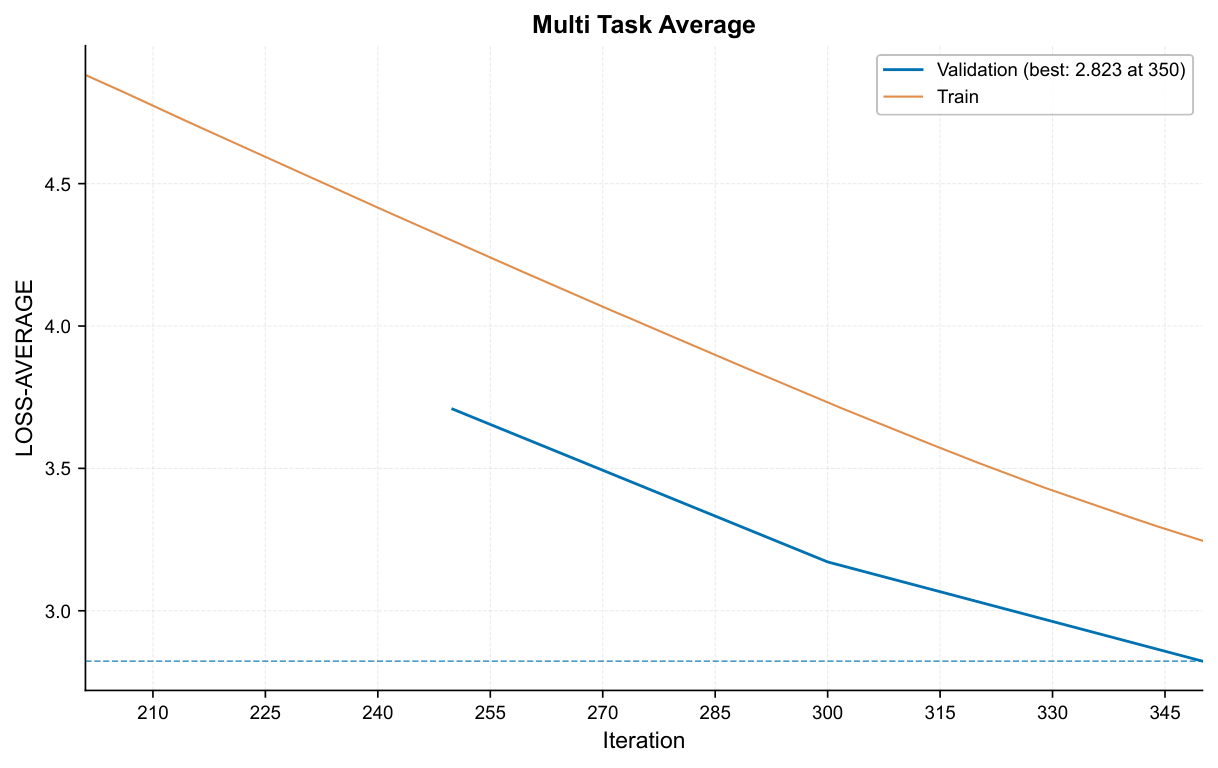

In [10]:
import fitz
from IPython.display import Image, display

doc = fitz.open("../runs/eir-intro-demo/training_curve_LOSS-AVERAGE.pdf")
page = doc.load_page(0)
pix = page.get_pixmap(dpi=150)

display(Image(data=pix.tobytes()))

> **Note**: the figure looks a bit strange here, so keep in mind what EIR is doing with it.
> It skips the first 200 iterations when plotting (`plot_skip_steps`), which normally gives
> a nicer view of the training once the loss has settled down a bit. Our run is only 350
> iterations in total though, so we are left with the last 150 of them, and with three
> points on the validation line since that is written every 50 iterations.
>
> Both curves are also still going down at the end, which we would expect from a run this
> short. In `03_eir-transformer.ipynb` the models train for 3000 iterations and the curves
> look more like what you might be used to.

# 5. The run folder

Everything goes into the `output_folder` from the global config, here `runs/eir-intro-demo/`:

```
runs/eir-intro-demo/
├── configs/                    the configs EIR actually resolved  <- read this, not your yaml
│   ├── global_config.yaml
│   ├── input_configs.yaml          includes inputs EIR invented for you
│   ├── fusion_config.yaml
│   └── output_configs.yaml
├── saved_models/               the checkpoint(s). n_saved_models: 1, so one file
├── serializations/             the vocabulary, so tokens map back to strings
├── latents/                    whatever latent_sampling asked for
├── results/                    generated sample sequences from each sample_interval
├── meta/                       EIR version and run metadata
├── model_architecture/         a text dump of the layers
├── logging_history.log         the training log
├── train_average_history.log   loss per iteration, as a csv
├── validation_average_history.log
├── training_curve_LOSS-AVERAGE.pdf    loss curves, already plotted
└── training_curve_PERF-AVERAGE.pdf
```

Two of these come up again later:

- **`configs/`** - the *resolved* configs (defaults filled in, inputs EIR generated). Where to look when something behaves unexpectedly
- **`serializations/`** - the vocabulary, without which the outputs are just integers. The later analyses load `serializations/sequence_output_serializations/ehr/vocab.json` to get `DX_I10` and the rest back

In [11]:
from pathlib import Path

run = Path("../runs/eir-intro-demo")
for p in sorted(run.iterdir()):
    print(("[dir] " if p.is_dir() else "      ") + p.name)

print("\nresolved configs:")
for p in sorted((run / "configs").iterdir()):
    print("      " + p.name)

[dir] configs
[dir] latents
      logging_history.log
[dir] meta
[dir] model_architecture
[dir] results
[dir] saved_models
[dir] serializations
      train_average_history.log
      training_curve_LOSS-AVERAGE.pdf
      training_curve_PERF-AVERAGE.pdf
      validation_average_history.log

resolved configs:
      fusion_config.yaml
      global_config.yaml
      input_configs.yaml
      output_configs.yaml


# 6. Applying a trained model with `eirpredict`

`eirtrain` learns the weights, `eirpredict` applies a trained checkpoint to new data.

In [12]:
!eirpredict --help

18:48:24 - INFO - eir.train_utils.utils - Global random seed set to 0.


usage: eirpredict [-h] [--global_configs [GLOBAL_CONFIGS ...]]
                  [--input_configs [INPUT_CONFIGS ...]]
                  [--fusion_configs [FUSION_CONFIGS ...]]
                  [--output_configs [OUTPUT_CONFIGS ...]]
                  --model_path MODEL_PATH [--evaluate]
                  --output_folder OUTPUT_FOLDER
                  [--attribution_background_source {train,predict}] [--strict]
                  [--no-strict]

options:
  -h, --help            show this help message and exit
  --global_configs [GLOBAL_CONFIGS ...]
                        Global .yaml configurations for the experiment.
  --input_configs [INPUT_CONFIGS ...]
                        Input feature extraction .yaml configurations. Each
                        configuration represents one input.
  --fusion_configs [FUSION_CONFIGS ...]
                        Fusion .yaml configurations.
  --output_configs [OUTPUT_CONFIGS ...]
                        Output .yaml configurations.
  --model_pat

DEL_PATH
                        Path to model to use for predictions.
  --evaluate
  --output_folder OUTPUT_FOLDER
                        Where to save prediction results.
  --attribution_background_source {train,predict}
                        For attribution analysis, whether to load backgrounds
                        from the data used for training or to use the current
                        data passed to the predict module.
  --strict              Enforce exact weight matching between checkpoint and
                        model (default: True). Fails if checkpoint and model
                        architectures don't match exactly.
  --no-strict           Allow partial weight loading. Use for transfer
                        learning or when intentionally loading a subset of
                        weights.


Two flags are required, and they are the two that are new:

| flag | meaning |
|---|---|
| `--model_path` | which checkpoint to load |
| `--output_folder` | where the predictions go. **Point this somewhere new**, reusing the training folder mixes results together |

The config flags are all optional now, and this time there is no catch, which comes down to the main idea here:

> `eirpredict` loads the training configs from the run folder first, and then **overrides** them with whatever we pass on the command line.

- So we only pass what *changes* at prediction time, in practice just the data paths
- Matching is by **name**, not by filename, so the `*_test.yaml` files keep their `input_name`/`output_name` and only change `input_source`/`output_source`
- Renaming adds a second input rather than replacing one
- The checkpoint filename carries the iteration number and validation score, so we look it up rather than hardcoding it

In [13]:
from pathlib import Path

checkpoint = next(Path("../runs/eir-intro-demo/saved_models").glob("*.pt"))
print(checkpoint)

../runs/eir-intro-demo/saved_models/eir-intro-demo_checkpoint_350_perf-average=-1.8231.pt


- The test output config changes `output_source`, i.e. it points the model at the test data
- The global config is passed because it carries `sample_interval`, which is what makes `eirpredict` actually *generate* sequences. Leave it off and the run still succeeds, but `results/` will be empty
- `--evaluate` says the new data has ground truth labels too, so compute the loss as well as the predictions

In [14]:
!eirpredict \
    --global_configs ../configs/eir-intro-demo/globals.yaml \
    --output_configs ../configs/eir-intro-demo/output_sequence_test.yaml \
    --model_path "{checkpoint}" \
    --evaluate \
    --output_folder ../runs/eir-intro-demo/test_set_predictions

18:48:35 - INFO - eir.train_utils.utils - Global random seed set to 0.


18:48:35 - INFO - eir.setup.config - Skipping input config name check for sequence input config (name='ehr') as it was automatically generated from a sequence output.
18:48:35 - INFO - eir.train_utils.metrics - Tabular output performance averaging functions across tasks set to averages of ['MCC', 'ROC-AUC-MACRO', 'AP-MACRO'] for categorical targets and ['1.0-LOSS', 'PCC', 'R2'] for continuous targets. These values are used to determine overall performance (using the validation set), which is used to control factors such as early stopping and LR scheduling. Other output cases (e.g. sequence generation, image generation) use 1.0-LOSS by default.
18:48:35 - DEBUG - eir.train_utils.metrics - All metrics are validation-only metrics, will skip all metric calculation for training batches.
18:48:35 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/eir-intro-demo/serializations/sequence_input_serializations/ehr/vocab.json.

18:48:35 - INFO - eir.predict_modules.predict_target_setup - Setting up target labels for ehr.
18:48:35 - INFO - eir.setup.input_setup - Setting up sequence inputs 'ehr' from ../reference_data/eir-intro-demo/df_ehr_demo_test.csv.
18:48:35 - INFO - eir.setup.input_setup_modules.setup_sequence - Vocabulary for None will be collected from vocabulary file ../runs/eir-intro-demo/serializations/sequence_input_serializations/ehr/vocab.json.
18:48:35 - INFO - eir.setup.input_setup_modules.setup_sequence - Minimum word/token frequency will be set to 0 as vocabulary is loaded from file ../runs/eir-intro-demo/serializations/sequence_input_serializations/ehr/vocab.json.
18:48:35 - WARNING - eir.experiment_io.input_object_io - Expected 'model_config' to be the same in current input configuration
'SequenceModelConfig(model_init_config=BasicTransformerFeatureExtractorModelConfig(num_heads=8, num_layers=4, dim_feedforward='auto', dropout=0.1), model_type='eir-input-sequence-from-linked-output-default'

18:48:35 - INFO - eir.models.model_setup_modules.model_io - Successfully loaded 103/103 modules from ../runs/eir-intro-demo/saved_models/eir-intro-demo_checkpoint_350_perf-average=-1.8231.pt.
18:48:35 - INFO - eir.train_utils.accelerator - Using accelerator: MPSAccelerator (auto-determined from 'auto')


18:48:35 - INFO - eir.train_utils.accelerator - Using strategy: SingleDeviceStrategy (auto-determined from 'auto')
18:48:35 - INFO - eir.train_utils.accelerator - Using precision: 32-true
18:48:35 - INFO - eir.train_utils.accelerator - Using devices: 1 (auto-determined from 'auto')
18:48:35 - INFO - eir.train_utils.accelerator - Using num_nodes: 1
18:48:35 - INFO - eir.train_utils.accelerator - Running in single-process mode


- The test loss should land near the last validation loss above
- `manual/` holds the continuations of the prompts we wrote into `sampling_config.manual_inputs`, i.e. the model showing us what it picked up about visit structure

In [15]:
import json
from pathlib import Path

pred = Path("../runs/eir-intro-demo/test_set_predictions")

metrics = json.loads((pred / "calculated_metrics.json").read_text())
print("test loss:", metrics["average"]["average"]["loss-average"])

sample = next((pred / "results/ehr/ehr/samples").iterdir())
print("\ncontinuation of the prompt 'SEX_2 [VISIT_START] AGE_59':\n")
print(sorted((sample / "manual").glob("*_generated.txt"))[0].read_text()[:400], "...")

test loss: 2.803604831695557

continuation of the prompt 'SEX_2 [VISIT_START] AGE_59':

SEX_2 [VISIT_START] AGE_59 LAB_HDL_cholesterol_74% LAB_Total_Triglycerides_62% LAB_Systolic_blood_pressure_automated_reading_40% [VISIT_END] [SEP] [VISIT_START] AGE_59 LAB_HDL_cholesterol_66% LAB_Body_mass_index_BMI_IMPED_40% LAB_Total_Triglycerides_56% DX_I10 [VISIT_END] [SEP] [VISIT_START] AGE_62 LAB_HDL_cholesterol_56% LAB_Body_mass_index_BMI_IMPED_52% LAB_Total_Triglycerides_44% LAB_Systolic_b ...


# 7. The latents

Section 2.1 had one key in the global config that we passed over, `latent_sampling`. Now that we have a run, we can look at what it wrote.

- Every `sample_interval` iterations, EIR ran the validation set through the model and saved the output of the named layer into `latents/`
- The layer we asked for, `output_modules.ehr.final_norm`, is the last one before the model predicts a token

In [16]:
import numpy as np
from pathlib import Path

latent_dir = Path("../runs/eir-intro-demo/latents/latent_outputs")
last_iteration = max(int(p.name) for p in latent_dir.iterdir() if p.name.isdigit())
latent_path = latent_dir / str(last_iteration) / "output_modules.ehr.final_norm"

latents = np.load(latent_path / "batch_00000.npy")

print("iteration:", last_iteration)
print("fields:", latents.dtype.names)
print("IDs:", latents["ID"][:4])
print("shape:", latents["Latent"].shape)

iteration: 350
fields: ('Latent', 'ID')
IDs: ['TRAIN_0001' 'TRAIN_0008' 'TRAIN_0014' 'TRAIN_0027']
shape: (150, 64, 64)


Those three numbers are easy to mix up, so taking them one at a time:

| number | count of | set by |
|---|---|---|
| **150** | patients | the validation split we fixed with `manual_valid_ids_file` (section 2.1) |
| **64** (middle) | **positions** in the sequence | `max_length: 64` (section 2.2) |
| **64** (last) | **numbers** used to write down one position | `embedding_dim: 64` (section 2.2) |

So a patient is not one vector here, but a **64 by 64 table**. Pulling out the real values for the first one:

```
TRAIN_0001            number1  number2  number3  number4  number5  ...  number64
position 1              -1.43     1.81     0.11     1.23     0.44  ...
position 2              -0.23     1.22     1.49     0.50    -0.94  ...
position 3               1.21    -1.80     1.39     0.92    -1.21  ...
 ...
position 64               ...
```

- **A row** is one token. The positions follow the order of that patient's sequence, which here starts `SEX_2 [VISIT_START] AGE_45 LAB_HDL_cholesterol_38% ...`
- **Averaging down the columns** leaves 64 numbers for the patient as a whole. That is 64 whether their record was long or short, so we can compare patients to each other

> **Note**: this patient has 49 tokens but 64 positions. Records shorter than `max_length` are padded at the end to match.

EIR also plots these while training, so a PCA of the same array is saved next to it.

per patient: (150, 64)


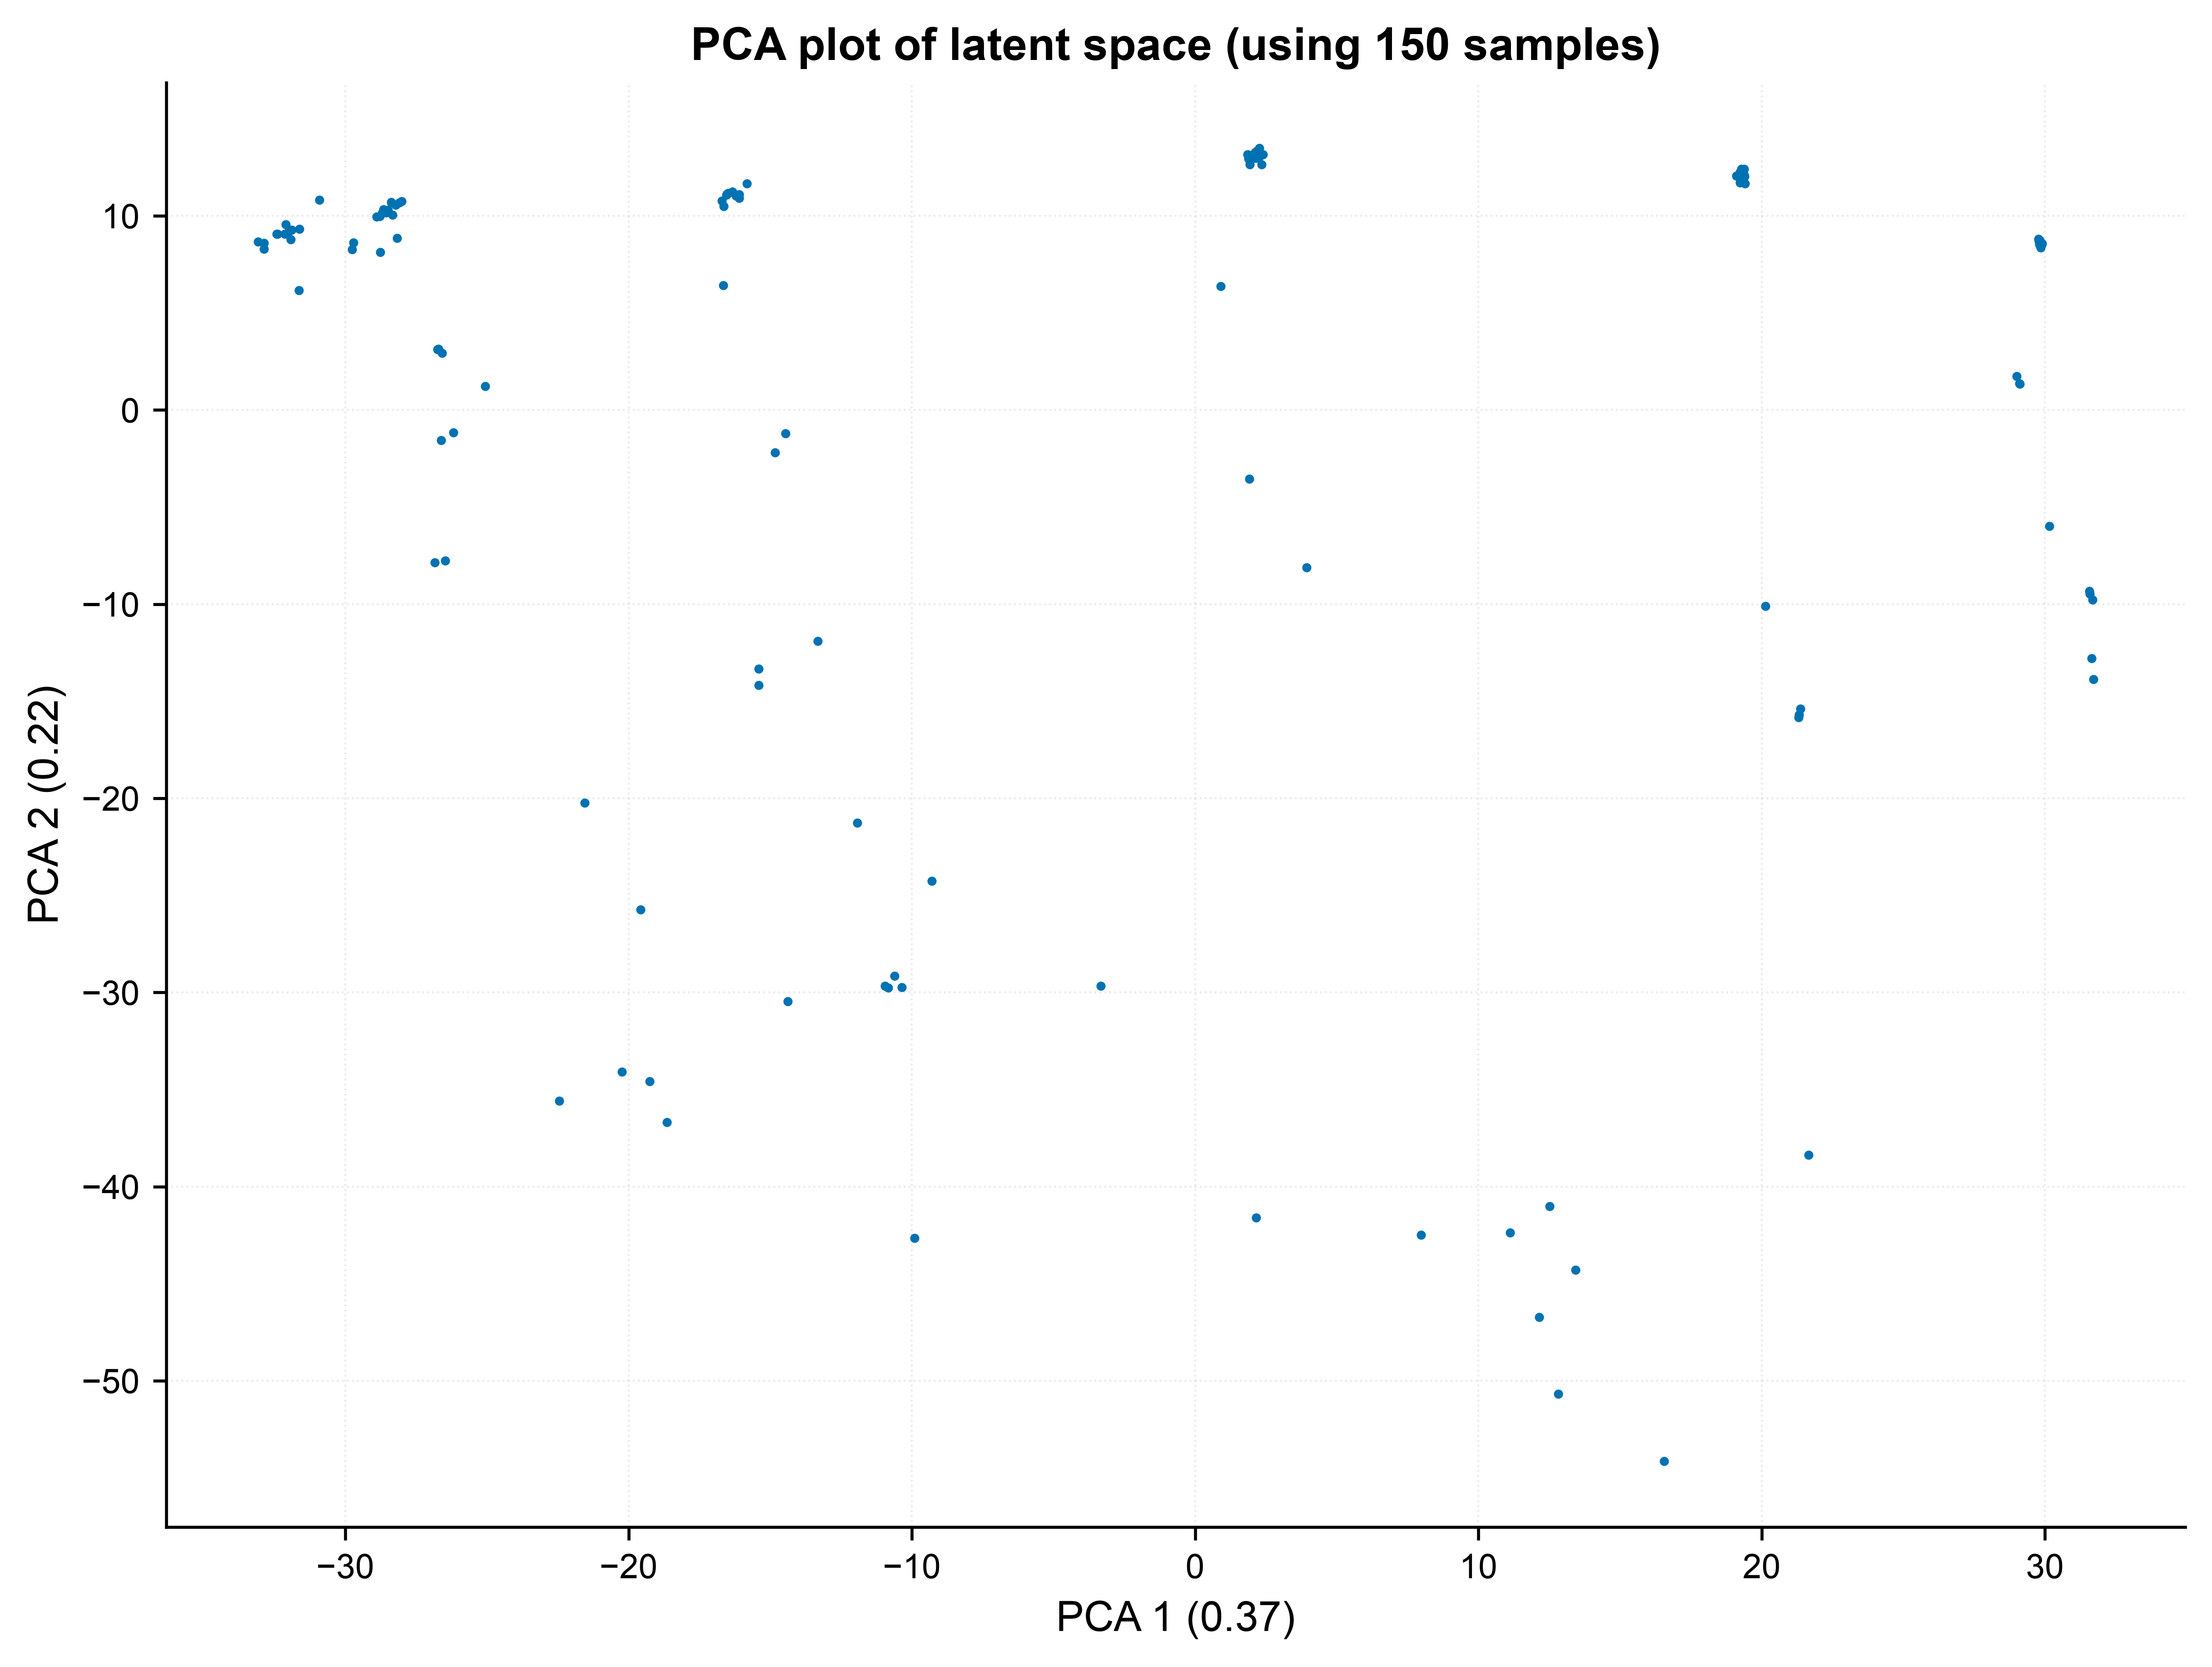

In [17]:
from IPython.display import Image

per_patient = latents["Latent"].mean(axis=1)
print("per patient:", per_patient.shape)

Image(filename=str(latent_path / "pca.png"))

> **Question**: can we say from this plot that similar patients group together? And what do the `0.37` and `0.22` on the axis labels mean?

<details>
<summary>Answers</summary>

- Not really, because the plot is unlabelled. As in the clustering section of `01_eir-fm-combined.ipynb`, we would first want to color the points by a known covariate (sex, age, a diagnosis) and see whether the structure aligns with anything we can name.
- The fraction of the total variance that component explains. PCA 1 holds 37% and PCA 2 holds 22%, so 59% between them, and the remaining 41% is in directions this plot does not show.

</details>

That is roughly what we would expect here, given that the demo data has no genetics in it and the model only saw 350 iterations. `03_eir-transformer.ipynb` does the same thing with a model that is worth interpreting, reducing with UMAP and coloring by GRS, to see whether individuals with similar genetics end up close to each other.

# 8. Summary

```
      configs/eir-transformer/
      ├── globals.yaml           how long, how fast, where to save
      ├── fusion.yaml            pass-through   (required for a sequence-only model)
      └── output_sequence.yaml   what to predict + model size
                    │
                    │   eirtrain --global_configs ... --fusion_configs ... --output_configs ...
                    ▼
      runs/ehr_transformer/
      ├── configs/               what EIR actually resolved
      ├── saved_models/          the checkpoint
      └── serializations/        the vocabulary
                    │
                    │   eirpredict --model_path <checkpoint> --output_folder <new dir>
                    │             (+ any config you want to override, e.g. the test csv)
                    ▼
      runs/ehr_transformer/test_set_predictions/
      ├── results/               generated sequences
      └── calculated_metrics.json
```

1. `--fusion_configs` is optional for the CLI but not for a sequence-only model, `--input_configs` genuinely is optional
2. A sequence generation model derives its input from the output config, so we do not write one
3. `eirpredict` overrides the training configs by **name**, so change `input_source`, never `input_name`
4. Run everything from `notebooks/`

# 9. Check yourself

1. We want 50 epochs instead of 20. Which file changes?
2. We want 8 transformer layers instead of 4. Which file changes?
3. Our model has one sequence output and no other inputs. Of the two optional flags, which
   one can we skip, and which one do we still need?
4. We asked for `num_layers: 4`, but the model diagram in the next notebook has 8
   transformer blocks. Where can we see what was actually built?
5. We run `eirtrain` from the repository root instead of from `notebooks/`. What happens?

<details>
<summary>Answers</summary>

1. `globals.yaml`, `n_epochs`. Training length applies to the run as a whole.
2. `output_sequence.yaml`, `model_config.model_init_config.num_layers`. Model size is set in
   the config for the output it belongs to.
3. We can skip `--input_configs`, since a sequence generation model derives its input from
   the output config. We still need `--fusion_configs`, because without it we get the
   default `mlp-residual`, and EIR does not accept that for a sequence-only output.
4. In `runs/<name>/model_architecture/` for the layers, and in `runs/<name>/configs/` for
   the resolved configs, where we can also see the input EIR made. There are 4 blocks on the
   input side and 4 on the output side, which is where the 8 comes from.
5. We get `Input source ../reference_data/... does not exist`. The paths in the configs are
   relative, and EIR resolves them from the directory we are running in rather than from the
   config file, so from the repository root they end up pointing outside it. Absolute paths
   would avoid this, but then they only work on one machine, so we keep the relative ones
   and run from `notebooks/`.

</details>

# 10. Where to go next

`03_eir-transformer.ipynb` picks up from here: it simulates the EHR trajectories, writes the configs we just read, runs `eirtrain`, and asks whether adding GRS values as a second input makes the model any better. Same mechanics, real simulation rather than a toy one.

**Reference**: the full config option list is at <https://eir.readthedocs.io/en/stable/> under Configuration Guides, where every key is documented along with its default.